In [89]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
import json

In [90]:
class EMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 47)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [91]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EMNIST_CNN().to(device)
model.load_state_dict(torch.load("emnist_model.pth", map_location=device))
model.eval()

C:\Users\Shail Patel\AppData\Local\Temp\ipykernel_14392\1286276928.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("emnist_model.pth", m

EMNIST_CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropo

In [92]:
with open("emnist_classes.json", "r") as f:
    classes = json.load(f)

In [93]:
import torch.nn.functional as F

def preprocess_image(image_path):
    
    image = Image.open(image_path).convert("L")
    
    # Convert to tensor
    tensor = transforms.ToTensor()(image)
    
    # Invert colors
    tensor = 1 - tensor
    
    # Binarize
    tensor = (tensor > 0.5).float()
    
    # Remove channel dimension temporarily for processing
    img = tensor.squeeze()
    
    # Find bounding box of white pixels
    coords = torch.nonzero(img)
    
    if coords.shape[0] == 0:
        raise ValueError("No character detected in image.")
    
    y_min, x_min = coords.min(dim=0).values
    y_max, x_max = coords.max(dim=0).values
    
    # Crop tightly
    cropped = img[y_min:y_max+1, x_min:x_max+1]
    
    # Resize cropped region to 28x28
    cropped = cropped.unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    resized = F.interpolate(cropped, size=(28,28), mode="bilinear", align_corners=False)
    
    resized = resized.squeeze(0)  # remove batch
    
    # Normalize
    resized = transforms.Normalize((0.5,), (0.5,))(resized)
    
    # Add batch dimension
    resized = resized.unsqueeze(0)
    
    plt.imshow(tensor.squeeze().cpu(), cmap="gray")
    plt.title("Processed Input")
    plt.show()
    
    return resized.to(device)


In [94]:
def predict(image_path):
    tensor = preprocess_image(image_path)
    
    with torch.no_grad():
        preds = model(tensor)
        probabilities = torch.softmax(preds, dim=1)
        
        confidence, predicted = torch.max(probabilities, 1)
        
    return classes[predicted.item()], confidence.item()

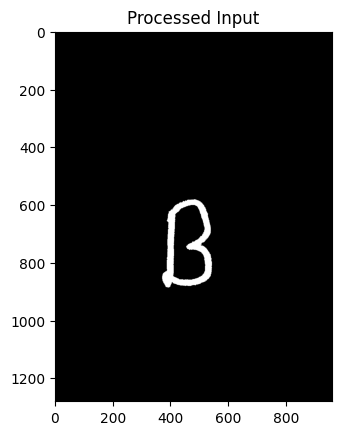

Prediction:  g
Confidence:  0.809277355670929


In [97]:
char, conf = predict("images/Camera_B.jpeg")
print("Prediction: ", char)
print("Confidence: ", conf)